In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import  tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense,Dropout,Bidirectional,SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model


import os
import re


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.
Path to dataset files: /kaggle/input/amazon-fine-food-reviews


In [ ]:
print(os.listdir(path))

['hashes.txt', 'Reviews.csv', 'database.sqlite']


In [ ]:
csv_file =os.path.join(path, 'Reviews.csv')
df= pd.read_csv(csv_file)
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
df.shape

(568454, 10)

In [ ]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [ ]:
df_clean=df[['Text','Score']]
df_clean.head(2)

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1


In [ ]:
for score in [1,2,3,4,5]:
  samplre_reviews=df_clean[df_clean['Score']==score]['Text'].iloc[0]
  print(f"\n star {score} review: \n")
  print(f"{samplre_reviews}")


 star 1 review: 

Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".

 star 2 review: 

If you are looking for the secret ingredient in Robitussin I believe I have found it.  I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda.  The flavor is very medicinal.

 star 3 review: 

This seems a little more wholesome than some of the supermarket brands, but it is somewhat mushy and doesn't have quite as much flavor either.  It didn't pass muster with my kids, so I probably won't buy it again.

 star 4 review: 

This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with powdered sugar.  And it is a tiny mouthful of heaven.  Not too chewy, and very flavorful.  I highly rec

In [ ]:
sort_data=df_clean['Score'].value_counts().sort_index()
for score, count in sort_data.items():
  per = count/len(df)*100
  print(f"{score}star: {count} {per:.2f}%")


1star: 52268 9.19%
2star: 29769 5.24%
3star: 42640 7.50%
4star: 80655 14.19%
5star: 363122 63.88%


In [ ]:
df_bianary =df_clean[df_clean['Score']!=3].copy()
df_bianary['sentiment']=(df_bianary['Score']>=4).astype(int)
df_bianary.head()

,Text,Score,sentiment
0,I have bought several of the Vitality canned d...,5,1
1,Product arrived labeled as Jumbo Salted Peanut...,1,0
2,This is a confection that has been around a fe...,4,1
3,If you are looking for the secret ingredient i...,2,0
4,Great taffy at a great price. There was a wid...,5,1


In [ ]:
print(f"Original data length: {len(df_clean)}")
print(f" Data length after removing 3 start {len(df_bianary)}")
print(f" sentiment 1  of lenth {len(df_bianary[df_bianary['sentiment']==1])}")
print(f" sentiment 0 of lenth {len(df_bianary[df_bianary['sentiment']==0])}")

Original data length: 568454
 Data length after removing 3 start 525814
 sentiment 1  of lenth 443777
 sentiment 0 of lenth 82037


In [ ]:
X=  df_bianary[['Text','Score']]
y=  df_bianary['sentiment']

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
RUS=RandomUnderSampler(random_state=42)
x_resample ,y_resample =RUS.fit_resample(X,y)

In [ ]:
y_resample.value_counts()


,count
sentiment,
0,82037
1,82037


In [ ]:
x_resample.shape

(164074, 2)

In [ ]:
y_resample.shape

(164074,)

In [ ]:
df_balance=pd.concat([x_resample,y_resample],axis=1)

In [ ]:
sample=50000
sample_data=df_balance.sample(n=sample)
print(f" sentiment 1 count {len(sample_data[sample_data['sentiment']==1])}")
print(f" sentiment 0 count {len(sample_data[sample_data['sentiment']==0])}")
sample_data.head()


 sentiment 1 count 24993
 sentiment 0 count 25007


,Text,Score,sentiment
154943,"Must say that this is some strong catnip,just ...",5,1
57437,"The texture of this cereal is nice, and<br /><...",4,1
392178,Received quickly. Watched videos at Breadtopia...,1,0
541070,an intense flavor experience from the axis of ...,4,1
69089,We do a lot of hiking and backpacking. I was ...,5,1


In [ ]:
sample_data.iloc[20]

,215391
Text,I have been searching for the 'right' balanced...
Score,5
sentiment,1


In [ ]:
def clean_text(text):
   text=text.lower()
   text= re.sub(r'<[^>]+>','',text)
   text= " ".join(text.split())
   return text


In [ ]:
sample_data['Text']=sample_data['Text'].apply(clean_text)
sample_data.head()

,Text,Score,sentiment
154943,"must say that this is some strong catnip,just ...",5,1
57437,"the texture of this cereal is nice, andthe swe...",4,1
392178,received quickly. watched videos at breadtopia...,1,0
541070,an intense flavor experience from the axis of ...,4,1
69089,we do a lot of hiking and backpacking. i was a...,5,1


In [ ]:
sample_data['Text'].iloc[20]

"i have been searching for the 'right' balanced english breakfast tea for a few years now. other than actual english teas from london, england, it was very difficult to find a rich and aromatic english breakfast.after trying out at least 20 different varieties, including some very expensive brands, i've found this to be the perfect cuppa in the morning. personally, loose leaf seems to taste a lot better to me, and i've not tried the tea-bag variety on this one.hope others enjoy this tea as much as i have."

In [ ]:
x=sample_data['Text'].values
y=sample_data['sentiment'].values

In [ ]:
MAX_FEATURES=10000
MAX_LEN=100

In [ ]:
tokenizer =Tokenizer(num_words=MAX_FEATURES,oov_token='<oov>')
tokenizer.fit_on_texts(x)


In [ ]:
tokenizer.word_index

{'<oov>': 1,
 'the': 2,
 'i': 3,
 'and': 4,
 'a': 5,
 'to': 6,
 'it': 7,
 'of': 8,
 'this': 9,
 'is': 10,
 'in': 11,
 'for': 12,
 'that': 13,
 'my': 14,
 'not': 15,
 'was': 16,
 'but': 17,
 'have': 18,
 'with': 19,
 'you': 20,
 'they': 21,
 'are': 22,
 'on': 23,
 'as': 24,
 'like': 25,
 'so': 26,
 'these': 27,
 'be': 28,
 'them': 29,
 'taste': 30,
 'at': 31,
 'one': 32,
 'product': 33,
 'or': 34,
 'just': 35,
 'good': 36,
 'if': 37,
 'all': 38,
 'very': 39,
 'from': 40,
 'coffee': 41,
 'had': 42,
 'would': 43,
 'food': 44,
 'flavor': 45,
 'when': 46,
 'me': 47,
 'more': 48,
 'will': 49,
 'can': 50,
 'we': 51,
 "it's": 52,
 'out': 53,
 'great': 54,
 'has': 55,
 'tea': 56,
 'no': 57,
 'other': 58,
 'get': 59,
 'about': 60,
 'than': 61,
 'up': 62,
 'were': 63,
 'love': 64,
 'only': 65,
 'some': 66,
 "don't": 67,
 'really': 68,
 'what': 69,
 'because': 70,
 'an': 71,
 'your': 72,
 'much': 73,
 'amazon': 74,
 'too': 75,
 'there': 76,
 'even': 77,
 'buy': 78,
 'do': 79,
 'she': 80,
 'time': 

In [ ]:
import pickle
with open('amazon_sentiment_tokenizer.pkl',"wb") as f:
    pickle.dump(tokenizer, f)


In [ ]:
x_sequence=tokenizer.texts_to_sequences(x)

In [ ]:
print(len(x_sequence[0]))
print(len(x_sequence[1]))


26
57


In [ ]:
x_padded=pad_sequences(x_sequence,maxlen=MAX_LEN,padding='post',truncating='post')


In [ ]:
len(x_padded[0])

100

In [ ]:
len(x_padded[20])

100

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x_padded,y,test_size=0.2,stratify=y)

In [ ]:
def create_rnn_model():
  model=Sequential([
      Embedding(MAX_FEATURES,128,input_length=MAX_LEN),
      SimpleRNN(64,return_sequences=False),
      Dropout(0.5),
      Dense(32,activation='relu'),
      Dense(1,activation='sigmoid')
  ])
  return model

In [ ]:
rnn_model= create_rnn_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
rnn_model.compile(
    optimizer='Adam',
    metrics=['accuracy'],
    loss='binary_crossentropy'
)

In [ ]:
print(x_train.shape)
print(y_train.shape)

(40000, 100)
(40000,)


In [ ]:
rnn_history = rnn_model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=5, #30? # epochs lesser -> 234,5 -> 150.   ->
    validation_split=0.20,
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.5150 - loss: 0.6947 - val_accuracy: 0.5332 - val_loss: 0.6893
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5484 - loss: 0.6784 - val_accuracy: 0.5449 - val_loss: 0.6798
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5982 - loss: 0.6231 - val_accuracy: 0.6471 - val_loss: 0.6676
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6266 - loss: 0.5672 - val_accuracy: 0.5652 - val_loss: 0.7655
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6503 - loss: 0.5241 - val_accuracy: 0.5381 - val_loss: 0.8485


In [ ]:
rnn_history.history

{'accuracy': [0.5150312781333923,
  0.5484374761581421,
  0.5982187390327454,
  0.6265624761581421,
  0.6503124833106995],
 'loss': [0.6947017908096313,
  0.6784164905548096,
  0.6230871677398682,
  0.5671960115432739,
  0.5240836143493652],
 'val_accuracy': [0.5332499742507935,
  0.5448750257492065,
  0.6471250057220459,
  0.5652499794960022,
  0.5381249785423279],
 'val_loss': [0.6893317103385925,
  0.6798465847969055,
  0.6676030158996582,
  0.7654775977134705,
  0.8485000133514404]}

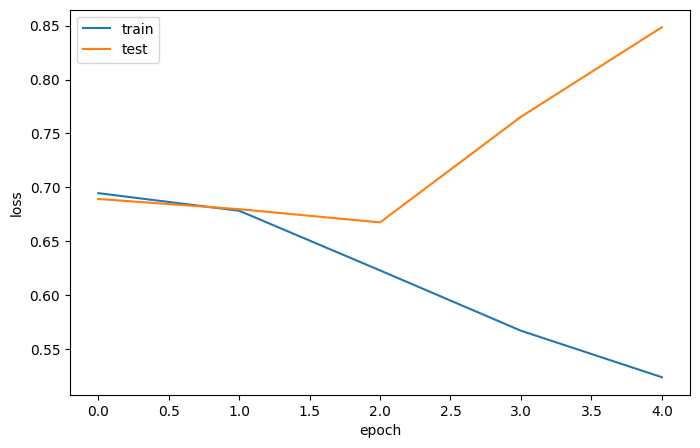

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(rnn_history.history['loss'],label='train')
plt.plot(rnn_history.history['val_loss'],label='test')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()
#

In [ ]:
def create_lstm_model():
  model=Sequential([
      Embedding(MAX_FEATURES,128,input_length=MAX_LEN),
      LSTM(64,return_sequences=False),
      Dropout(0.5),
      Dense(32,activation='relu'),
      Dense(1,activation='sigmoid')
  ])
  return model

In [ ]:
lstm_model= create_lstm_model()

In [ ]:
lstm_model.compile(
    optimizer='Adam',
    metrics=['accuracy'],
    loss='binary_crossentropy'
)

In [ ]:
lstm_history = lstm_model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=5, #30? # epochs lesser -> 234,5 -> 150.   ->
    validation_split=0.20)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5469 - loss: 0.6847 - val_accuracy: 0.5437 - val_loss: 0.6795
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6004 - loss: 0.6594 - val_accuracy: 0.6421 - val_loss: 0.6580
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6320 - loss: 0.6407 - val_accuracy: 0.6503 - val_loss: 0.6290
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6442 - loss: 0.6373 - val_accuracy: 0.6572 - val_loss: 0.6130
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7079 - loss: 0.5756 - val_accuracy: 0.7281 - val_loss: 0.5491


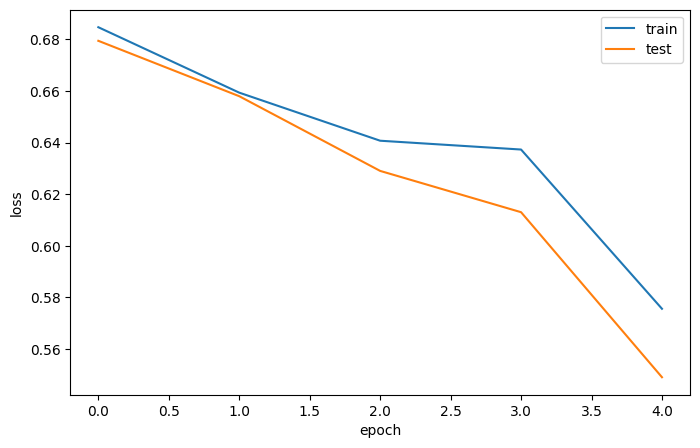

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(lstm_history.history['loss'],label='train')
plt.plot(lstm_history.history['val_loss'],label='test')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

hyperparameter tuning using baysian optimization

In [ ]:
!pip install keras-tuner -q

In [ ]:
import keras_tuner as kt

In [ ]:
def build_model(hp):
    model= Sequential()
    #embeding layer
    model.add(Embedding(MAX_FEATURES,hp.Choice('embedding_dim',[128,256,512]),input_length=MAX_LEN))
    # choice of model type
    model_type = hp.Choice('model_type',['LSTM','RNN'])
    units = hp.Choice('units',[16,32,64,128,256])

    if model_type == 'LSTM':
      model.add(LSTM(units,return_sequences=False))
    else:
      model.add(SimpleRNN(units,return_sequences=False))
    model.add(Dropout(hp.Choice('dropout',[0.1,0.3,0.5])))
    model.add(Dense(32,activation='relu'))
    model.add(Dense(1,activation='sigmoid'))
    learning_rate = hp.Choice('learning_rate',[1e-2,1e-3,1e-4])
    model.compile(
        optimizer='Adam',
        metrics=['accuracy'],
        loss='binary_crossentropy'
    )


    return model




In [ ]:
tuner = kt.BayesianOptimization(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    directory='bayesian_tuning',
    project_name='amazon_review_sentiment_analysis'
)

Reloading Tuner from bayesian_tuning/amazon_review_sentiment_analysis/tuner0.json


In [ ]:
tuner.search_space_summary()

Search space summary
Default search space size: 5
embedding_dim (Choice)
{'default': 128, 'conditions': [], 'values': [128, 256, 512], 'ordered': True}
model_type (Choice)
{'default': 'LSTM', 'conditions': [], 'values': ['LSTM', 'RNN'], 'ordered': False}
units (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64, 128, 256], 'ordered': True}
dropout (Choice)
{'default': 0.1, 'conditions': [], 'values': [0.1, 0.3, 0.5], 'ordered': True}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint


In [ ]:
tuner.search(x_train,y_train,
            epochs=3,
             batch_size=128,
             validation_split=0.2,
             callbacks=[early_stop]
             )

In [ ]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

In [ ]:
best_hps.values

{'embedding_dim': 512,
 'model_type': 'LSTM',
 'units': 32,
 'dropout': 0.5,
 'learning_rate': 0.001}

In [ ]:
best_model=build_model(best_hps)

In [ ]:
history = best_model.fit(
    x_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split = 0.20,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)],
)

Epoch 1/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.5678 - loss: 0.6672 - val_accuracy: 0.7724 - val_loss: 0.4967
Epoch 2/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.8672 - loss: 0.3387 - val_accuracy: 0.8811 - val_loss: 0.2874
Epoch 3/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9247 - loss: 0.2052 - val_accuracy: 0.8846 - val_loss: 0.2959
Epoch 4/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9529 - loss: 0.1355 - val_accuracy: 0.8852 - val_loss: 0.3284
Epoch 5/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9689 - loss: 0.0934 - val_accuracy: 0.8824 - val_loss: 0.3508
Epoch 6/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9804 - loss: 0.0612 - val_accuracy: 0.8790 - val_loss: 0.4623
Epoch 7/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9846 - loss: 0.0499 - val_accuracy: 0.8820 - val_loss: 0.4513
Epoch 8/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 

In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

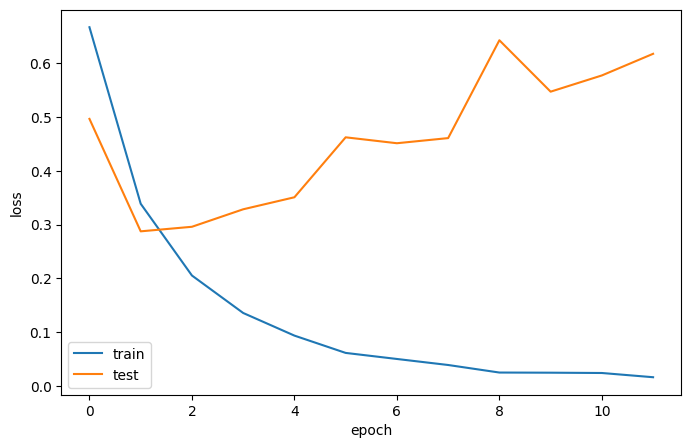

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

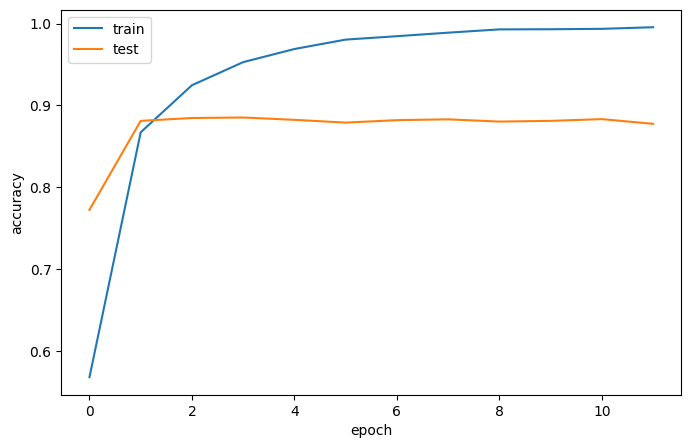

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='test')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()

In [ ]:
loss, accuracy = best_model.evaluate(x_test, y_test)
print(f"loss : {loss}")
print(f"accuracy : {accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8881 - loss: 0.2722
loss : 0.2721727192401886
accuracy : 0.8881000280380249


In [ ]:
best_model.save("best_review_model.keras")

In [ ]:
with open('amazon_sentiment_tokenizer.pkl','rb') as f:
  loaded_tokenizer = pickle.load(f)

In [ ]:
test_sentences = ['this product is really good, i am a big fan of this',
                  "terrible quality, waste of my money <br><br>",
                  "great food, amazing quality can do better but for now i am happy"]

In [ ]:

def predict_sentiment(text):
 text= clean_text(text)
 sequence = loaded_tokenizer.texts_to_sequences([text])
 padded_sequence = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')
 prediction = best_model.predict(padded_sequence)
 sentiment = "positive" if prediction > 0.5 else "negative"
 return sentiment, prediction[0][0]


In [ ]:
predict_sentiment(test_sentences[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


('positive', np.float32(0.9666477))

In [ ]:
predict_sentiment(test_sentences[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


('negative', np.float32(0.017837424))